Accelerations shape: (50, 72000)
Mean modal mass ratios shape: (50,)
Overall mean modal mass ratio = 0.009935977528620804
Overall std modal mass ratio  = 0.00010184010299700825


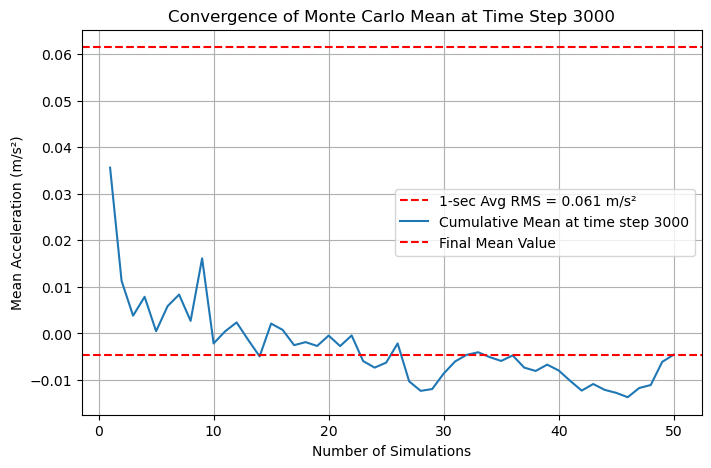

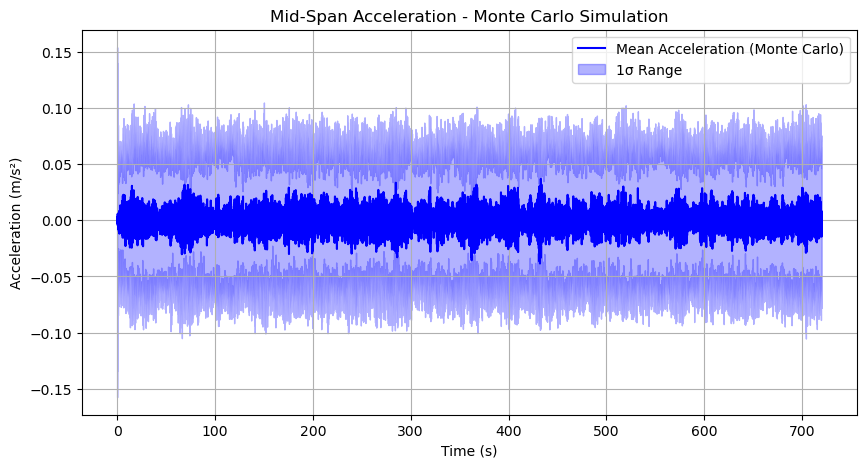

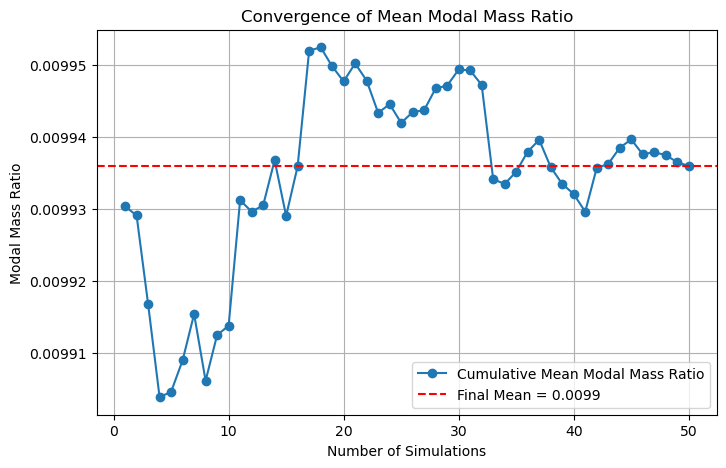

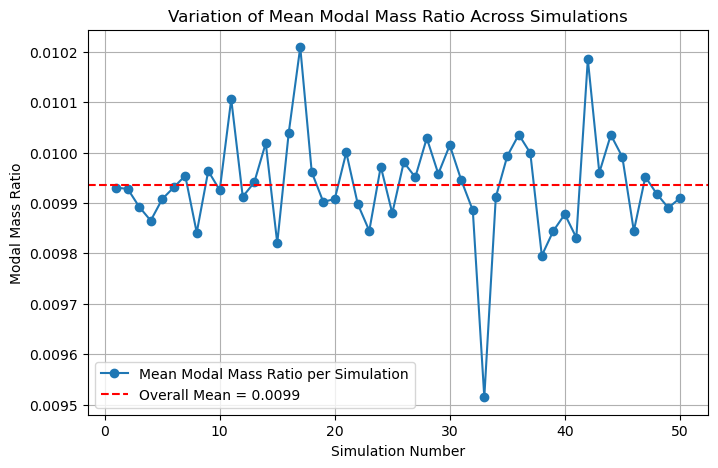

In [12]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing 
import numpy as np
import torch
import socialforce
import matplotlib.pyplot as plt
from socialforcefunctions import initial_state_corridor
from solver import Newmarksuper_HSIsocial, compute_1sec_rms_mean
from matrix import bridge
from pedestrian import Pedestrian
from eeklovarification import run_simulation

# Define Monte Carlo settings
NUM_SIMULATIONS = 50  # Number of Monte Carlo runs (increase for better statistics)
NUM_PROCESSES = 10  # Use all available CPU cores
hht = 0.01

# Using multiprocessing Pool to parallelize the simulations
if __name__ == "__main__":
    with multiprocessing.Pool(processes=NUM_PROCESSES) as pool:
        peddamp = 0.30
        pedBodyF = 3.10
        Tocity = 32
        Outcity = 31
        Length = 96
        Width = 3
        simulation_duration = 720.0  # seconds
        args_list = [(None, peddamp, pedBodyF,Tocity, Outcity, Length, Width, simulation_duration) for _ in range(NUM_SIMULATIONS)]
        results = pool.map(run_simulation, args_list)

    # Convert results to NumPy array for statistical processing
    accelerations = [r[0] for r in results]
    mean_mass_ratios = [r[1] for r in results]

    # Convert to NumPy arrays
    accelerations = np.array(accelerations)         # shape: (num_sims, n_time_steps)
    mean_mass_ratios = np.array(mean_mass_ratios)   # shape: (num_sims,)

    print("Accelerations shape:", accelerations.shape)
    print("Mean modal mass ratios shape:", mean_mass_ratios.shape)

 # --------------------------------------------------
    # Acceleration statistics
    # --------------------------------------------------
    mean_acceleration = np.mean(accelerations, axis=0)
    std_acceleration = np.std(accelerations, axis=0)

    # --------------------------------------------------
    # Cumulative mean of acceleration
    # --------------------------------------------------
    cumulative_means = np.array([
        np.mean(accelerations[:i+1], axis=0) for i in range(NUM_SIMULATIONS)
    ])

    # Pick a specific time step to check convergence
    time_step = 3000
    convergence_curve = cumulative_means[:, time_step]

    # Compute 1-second average RMS
    avg_1sec_rms = compute_1sec_rms_mean(accelerations, int(1 / hht))

    # Time vector
    t = np.arange(accelerations.shape[1]) * hht

    # --------------------------------------------------
    # Modal mass ratio statistics
    # --------------------------------------------------
    overall_mean_mass_ratio = np.mean(mean_mass_ratios)
    overall_std_mass_ratio = np.std(mean_mass_ratios)

    # Cumulative mean modal mass ratio
    sim_numbers = np.arange(1, NUM_SIMULATIONS + 1)
    cumulative_mean_mass_ratio = np.cumsum(mean_mass_ratios) / sim_numbers

    print("Overall mean modal mass ratio =", overall_mean_mass_ratio)
    print("Overall std modal mass ratio  =", overall_std_mass_ratio)

    # --------------------------------------------------
    # Plot 1: Acceleration convergence at selected time step
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.axhline(avg_1sec_rms, color='red', linestyle='--',
                label=f'1-sec Avg RMS = {avg_1sec_rms:.3f} m/s²')
    plt.plot(sim_numbers, convergence_curve, label=f"Cumulative Mean at time step {time_step}")
    plt.axhline(y=convergence_curve[-1], color='r', linestyle="--", label="Final Mean Value")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Mean Acceleration (m/s²)")
    plt.title(f"Convergence of Monte Carlo Mean at Time Step {time_step}")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 2: Mean acceleration time history
    # --------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(t, mean_acceleration, label="Mean Acceleration (Monte Carlo)", color='b')
    plt.fill_between(
        t,
        mean_acceleration - std_acceleration,
        mean_acceleration + std_acceleration,
        color='b',
        alpha=0.3,
        label="1σ Range"
    )
    plt.title("Mid-Span Acceleration - Monte Carlo Simulation")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 3: Cumulative mean of modal mass ratio
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, cumulative_mean_mass_ratio, marker='o',
             label="Cumulative Mean Modal Mass Ratio")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Final Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Convergence of Mean Modal Mass Ratio")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 4: Variation of modal mass ratio across simulations
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, mean_mass_ratios, marker='o', linestyle='-',
             label="Mean Modal Mass Ratio per Simulation")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Overall Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Simulation Number")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Variation of Mean Modal Mass Ratio Across Simulations")
    plt.legend()
    plt.grid()
    plt.show()

In [13]:
import pickle

save_data = {
    "accelerations": accelerations,
    "mean_mass_ratios": mean_mass_ratios,
    "time": t,
    "hht": hht,
}

filename = f"W073_free1_MC{NUM_SIMULATIONS}.pkl"

with open(filename, "wb") as file:
    pickle.dump(save_data, file)

print(f"Saved: {filename}")

Saved: W073_free1_MC50.pkl


Top-level entries:
  #refs#
  body_accelerations
  general
  structural_accelerations
  trajectories

Structural acceleration entries:
  loc_sensors: shape=(2, 10), type=<class 'h5py._hl.dataset.Dataset'>
  sensors: shape=(10, 1), type=<class 'h5py._hl.dataset.Dataset'>
  x: shape=(10, 80274), type=<class 'h5py._hl.dataset.Dataset'>
  y: shape=(10, 80274), type=<class 'h5py._hl.dataset.Dataset'>
  z: shape=(10, 80274), type=<class 'h5py._hl.dataset.Dataset'>

Raw z shape: (10, 80274)
Sensors: [194 213 214 215 491 494 824 825 826 828]
Corrected z shape: (80274, 10)
Sensor 214 is column 2 in Python and column 3 in MATLAB.
Samples            = 80274
Duration           = 720.000 s
Estimated dt       = 0.008969 s
Estimated frequency = 111.492 Hz
Peak absolute acceleration = 1.090776 m/s²
95% absolute acceleration  = 0.268172 m/s²


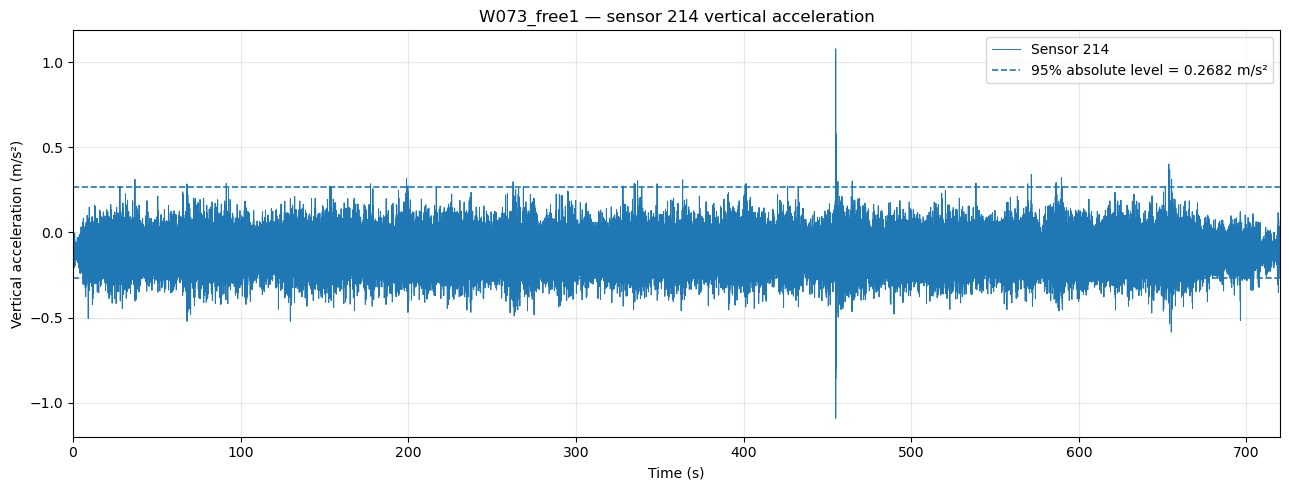

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path


# ================================================================
# FILE
# ================================================================

mat_file = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set\W073_free1.mat"
)

if not mat_file.exists():
    raise FileNotFoundError(f"File not found:\n{mat_file}")


# ================================================================
# INSPECT AND LOAD MATLAB v7.3 FILE
# ================================================================

with h5py.File(mat_file, "r") as f:

    print("Top-level entries:")
    for key in f.keys():
        print(" ", key)

    print("\nStructural acceleration entries:")
    for key in f["structural_accelerations"].keys():
        obj = f["structural_accelerations"][key]
        print(
            f"  {key}: "
            f"shape={getattr(obj, 'shape', None)}, "
            f"type={type(obj)}"
        )

    # Read vertical acceleration and sensor numbers
    z_accelerations = np.array(
        f["structural_accelerations"]["z"]
    )

    sensor_numbers = np.array(
        f["structural_accelerations"]["sensors"]
    ).squeeze()


# ================================================================
# CLEAN SENSOR NUMBERS
# ================================================================

sensor_numbers = sensor_numbers.astype(int).ravel()

print("\nRaw z shape:", z_accelerations.shape)
print("Sensors:", sensor_numbers)


# ================================================================
# FIX MATLAB/HDF5 ORIENTATION
# ================================================================
# MATLAB v7.3 arrays often appear transposed in h5py.
# We want:
#     rows    = time samples
#     columns = sensors

number_of_sensors = len(sensor_numbers)

if z_accelerations.shape[1] == number_of_sensors:

    # Already samples × sensors
    z_accelerations = z_accelerations

elif z_accelerations.shape[0] == number_of_sensors:

    # Currently sensors × samples
    z_accelerations = z_accelerations.T

else:
    raise ValueError(
        "Could not match the acceleration matrix to the sensor list.\n"
        f"Acceleration shape: {z_accelerations.shape}\n"
        f"Number of sensors: {number_of_sensors}"
    )

print("Corrected z shape:", z_accelerations.shape)


# ================================================================
# EXTRACT SENSOR 214
# ================================================================

target_sensor = 214

matching_indices = np.where(
    sensor_numbers == target_sensor
)[0]

if len(matching_indices) == 0:
    raise ValueError(
        f"Sensor {target_sensor} was not found.\n"
        f"Available sensors: {sensor_numbers.tolist()}"
    )

sensor_column = int(matching_indices[0])

acceleration_214 = z_accelerations[:, sensor_column]

print(
    f"Sensor {target_sensor} is column {sensor_column} in Python "
    f"and column {sensor_column + 1} in MATLAB."
)


# ================================================================
# TIME VECTOR
# ================================================================
# W073_free1 has a reported duration of 720 seconds.

duration = 720.0

number_of_samples = len(acceleration_214)

time = np.linspace(
    0.0,
    duration,
    number_of_samples,
    endpoint=False
)

dt = duration / number_of_samples
sampling_frequency = 1.0 / dt

print(f"Samples            = {number_of_samples}")
print(f"Duration           = {duration:.3f} s")
print(f"Estimated dt       = {dt:.6f} s")
print(f"Estimated frequency = {sampling_frequency:.3f} Hz")


# ================================================================
# RESPONSE MEASURES
# ================================================================

peak_absolute = float(
    np.max(np.abs(acceleration_214))
)

p95_absolute = float(
    np.percentile(
        np.abs(acceleration_214),
        95
    )
)

print(
    f"Peak absolute acceleration = "
    f"{peak_absolute:.6f} m/s²"
)

print(
    f"95% absolute acceleration  = "
    f"{p95_absolute:.6f} m/s²"
)


# ================================================================
# PLOT
# ================================================================

plt.figure(figsize=(13, 5))

plt.plot(
    time,
    acceleration_214,
    linewidth=0.7,
    label="Sensor 214"
)

plt.axhline(
    p95_absolute,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"95% absolute level = "
        f"{p95_absolute:.4f} m/s²"
    )
)

plt.axhline(
    -p95_absolute,
    linestyle="--",
    linewidth=1.2
)

plt.xlabel("Time (s)")
plt.xlim(0, 720)
plt.ylabel("Vertical acceleration (m/s²)")
plt.title("W073_free1 — sensor 214 vertical acceleration")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


MATLAB data
-----------
Raw z-acceleration shape: (10, 80274)
Available sensors: [194 213 214 215 491 494 824 825 826 828]
Corrected z-acceleration shape: (80274, 10)
Sensor 214 corresponds to Python column 2.
Measured samples       = 80274
Estimated measured dt  = 0.008969 s
Estimated measured fs  = 111.492 Hz

Response comparison
-------------------
Measured peak absolute acceleration  = 1.189498 m/s²
Simulated peak absolute acceleration = 0.262539 m/s²
Measured P95 absolute acceleration   = 0.188863 m/s²
Simulated P95 absolute acceleration  = 0.121812 m/s²


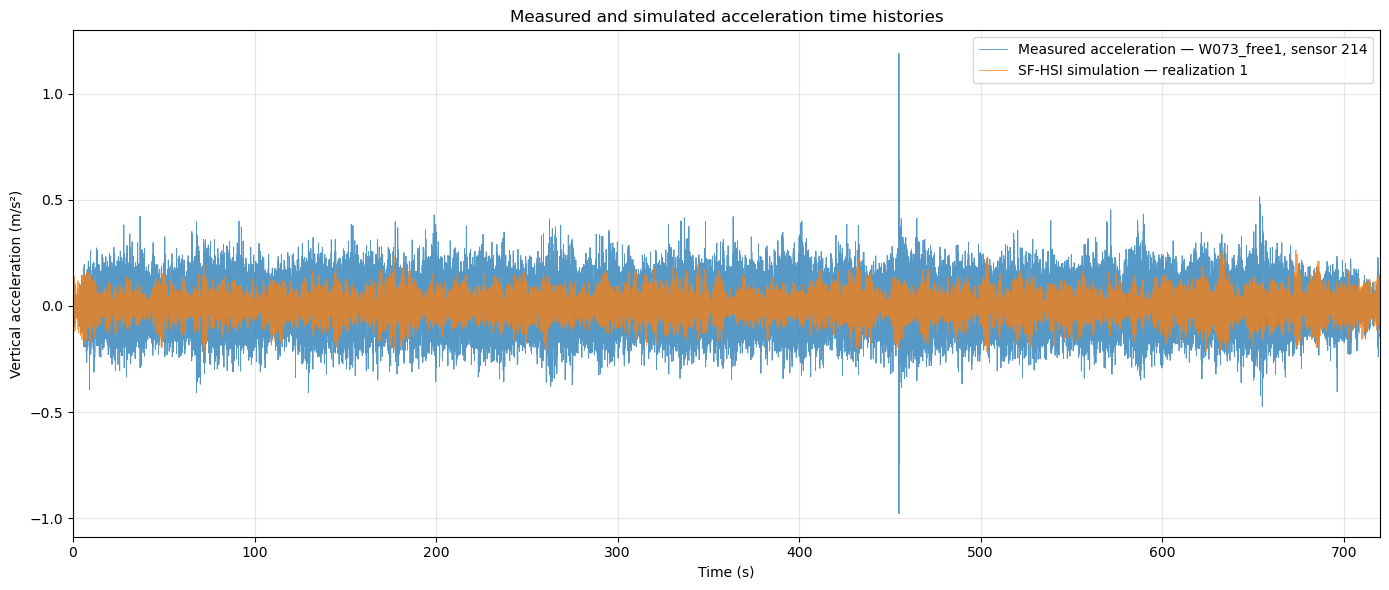

In [14]:
# ================================================================
# COMPARE SF-HSI SIMULATION WITH MATLAB MEASUREMENT — SENSOR 214
# ================================================================

import h5py
from pathlib import Path


# ------------------------------------------------
# MATLAB file
# ------------------------------------------------

mat_file = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set\W073_free1.mat"
)

target_sensor = 214
measured_duration = 720.0  # seconds


if not mat_file.exists():
    raise FileNotFoundError(
        f"MATLAB file was not found:\n{mat_file}"
    )


# ------------------------------------------------
# Load MATLAB v7.3 data
# ------------------------------------------------

with h5py.File(mat_file, "r") as mat_data:

    z_accelerations = np.asarray(
        mat_data["structural_accelerations"]["z"],
        dtype=float
    )

    sensor_numbers = np.asarray(
        mat_data["structural_accelerations"]["sensors"]
    ).squeeze().astype(int)


sensor_numbers = sensor_numbers.ravel()

print("\nMATLAB data")
print("-----------")
print("Raw z-acceleration shape:", z_accelerations.shape)
print("Available sensors:", sensor_numbers)


# ------------------------------------------------
# Correct orientation
#
# Required final shape:
#     rows    = time samples
#     columns = sensors
# ------------------------------------------------

number_of_sensors = len(sensor_numbers)

if z_accelerations.shape[1] == number_of_sensors:

    # Already samples × sensors
    pass

elif z_accelerations.shape[0] == number_of_sensors:

    # h5py often returns MATLAB arrays transposed
    z_accelerations = z_accelerations.T

else:

    raise ValueError(
        "The dimensions of the acceleration matrix do not match "
        "the number of sensors.\n"
        f"Acceleration shape = {z_accelerations.shape}\n"
        f"Number of sensors  = {number_of_sensors}"
    )


print("Corrected z-acceleration shape:", z_accelerations.shape)


# ------------------------------------------------
# Find sensor 214
# ------------------------------------------------

matching_columns = np.where(
    sensor_numbers == target_sensor
)[0]

if len(matching_columns) == 0:

    raise ValueError(
        f"Sensor {target_sensor} was not found.\n"
        f"Available sensors: {sensor_numbers.tolist()}"
    )


sensor_column = int(
    matching_columns[0]
)

measured_acceleration = z_accelerations[
    :,
    sensor_column
].copy()


print(
    f"Sensor {target_sensor} corresponds to "
    f"Python column {sensor_column}."
)


# ------------------------------------------------
# Remove constant measurement offset
# ------------------------------------------------

measured_acceleration = (
    measured_acceleration
    - np.mean(measured_acceleration)
)


# ------------------------------------------------
# MATLAB time vector
# ------------------------------------------------

number_of_measured_samples = len(
    measured_acceleration
)

time_measured = np.linspace(
    0.0,
    measured_duration,
    number_of_measured_samples,
    endpoint=False
)

measured_dt = (
    measured_duration
    / number_of_measured_samples
)

measured_fs = (
    1.0
    / measured_dt
)


print(
    f"Measured samples       = "
    f"{number_of_measured_samples}"
)

print(
    f"Estimated measured dt  = "
    f"{measured_dt:.6f} s"
)

print(
    f"Estimated measured fs  = "
    f"{measured_fs:.3f} Hz"
)


# ------------------------------------------------
# Select simulated history
# ------------------------------------------------
# Use the first stochastic realization when NUM_SIMULATIONS = 1.
# For several simulations, change this to mean_acceleration if desired.

simulated_acceleration = accelerations[0].copy()

# Remove any small numerical offset
simulated_acceleration = (
    simulated_acceleration
    - np.mean(simulated_acceleration)
)

time_simulated = (
    np.arange(
        len(simulated_acceleration)
    )
    * hht
)


# ------------------------------------------------
# Calculate response measures
# ------------------------------------------------

measured_peak = float(
    np.max(
        np.abs(measured_acceleration)
    )
)

simulated_peak = float(
    np.max(
        np.abs(simulated_acceleration)
    )
)

measured_p95 = float(
    np.percentile(
        np.abs(measured_acceleration),
        95
    )
)

simulated_p95 = float(
    np.percentile(
        np.abs(simulated_acceleration),
        95
    )
)


print("\nResponse comparison")
print("-------------------")

print(
    f"Measured peak absolute acceleration  = "
    f"{measured_peak:.6f} m/s²"
)

print(
    f"Simulated peak absolute acceleration = "
    f"{simulated_peak:.6f} m/s²"
)

print(
    f"Measured P95 absolute acceleration   = "
    f"{measured_p95:.6f} m/s²"
)

print(
    f"Simulated P95 absolute acceleration  = "
    f"{simulated_p95:.6f} m/s²"
)


# ------------------------------------------------
# Plot both histories
# ------------------------------------------------

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    time_measured,
    measured_acceleration,
    linewidth=0.65,
    alpha=0.75,
    label=(
        "Measured acceleration — "
        "W073_free1, sensor 214"
    )
)

plt.plot(
    time_simulated,
    simulated_acceleration,
    linewidth=0.65,
    alpha=0.75,
    label="SF-HSI simulation — realization 1"
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Vertical acceleration (m/s²)"
)

plt.title(
    "Measured and simulated acceleration time histories"
)

plt.xlim(
    0.0,
    min(
        time_measured[-1],
        time_simulated[-1]
    )
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()
plt.tight_layout()
plt.show()


P95 1-second RMS results
 Simulation Measured P95 1-sec RMS (m/s²) Simulated P95 1-sec RMS (m/s²) Bias measured/simulated
          1                      0.121580                       0.095114                  1.2783
          2                      0.121580                       0.112988                  1.0760
          3                      0.121580                       0.095322                  1.2755
          4                      0.121580                       0.093424                  1.3014
          5                      0.121580                       0.095018                  1.2795
          6                      0.121580                       0.089270                  1.3619
          7                      0.121580                       0.104434                  1.1642
          8                      0.121580                       0.088149                  1.3793
          9                      0.121580                       0.115844                  1.0495
    

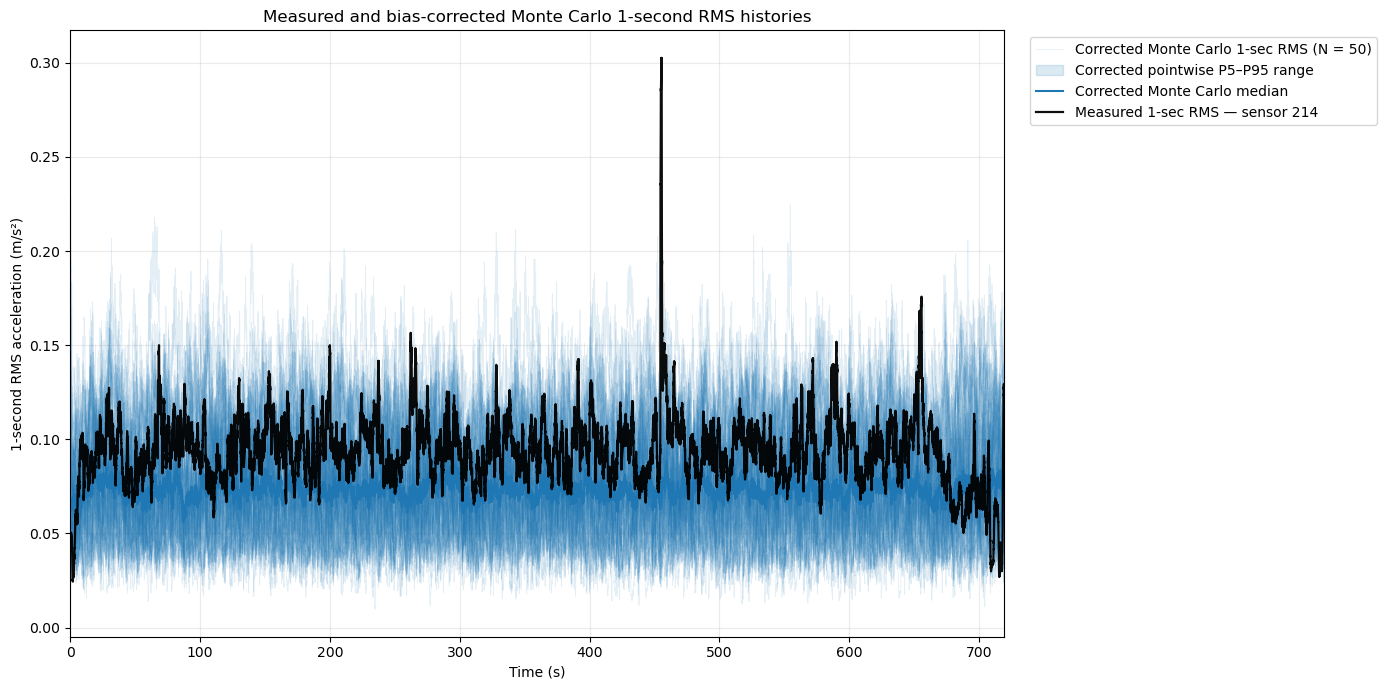

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# SETTINGS
# ================================================================

RMS_WINDOW_SECONDS = 1.0
REMOVE_MEAN = True

# Bias convention:
# bias = measured / simulated
#
# bias > 1  -> model underpredicts
# bias < 1  -> model overpredicts
# bias = 1  -> exact agreement


# ================================================================
# MOVING 1-SECOND RMS
# ================================================================

def calculate_moving_rms(
    acceleration,
    dt,
    window_seconds=1.0,
):
    """
    Calculate a moving RMS time history using complete windows.

    The time assigned to each RMS value is the centre of the
    corresponding RMS window.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float
    ).squeeze()

    if acceleration.ndim != 1:
        raise ValueError(
            "Acceleration must be one-dimensional."
        )

    if dt <= 0.0:
        raise ValueError(
            "Time step dt must be positive."
        )

    window_samples = int(
        round(window_seconds / dt)
    )

    if window_samples < 1:
        raise ValueError(
            "The RMS window contains fewer than one sample."
        )

    if len(acceleration) < window_samples:
        raise ValueError(
            "The acceleration history is shorter than "
            "the RMS window."
        )

    kernel = (
        np.ones(
            window_samples,
            dtype=float
        )
        / window_samples
    )

    moving_mean_square = np.convolve(
        acceleration**2,
        kernel,
        mode="valid"
    )

    moving_rms = np.sqrt(
        np.maximum(
            moving_mean_square,
            0.0
        )
    )

    time_rms = (
        np.arange(
            len(moving_rms),
            dtype=float
        )
        + (window_samples - 1) / 2.0
    ) * dt

    return time_rms, moving_rms


# ================================================================
# PREPARE MEASURED ACCELERATION
# ================================================================

measured_acceleration_input = np.asarray(
    measured_acceleration,
    dtype=float
).squeeze()

time_measured_input = np.asarray(
    time_measured,
    dtype=float
).squeeze()

if measured_acceleration_input.ndim != 1:
    raise ValueError(
        "measured_acceleration must be one-dimensional."
    )

if len(measured_acceleration_input) != len(time_measured_input):
    raise ValueError(
        "measured_acceleration and time_measured must "
        "have the same length."
    )

if len(time_measured_input) < 2:
    raise ValueError(
        "The measured time vector must contain at least two values."
    )

measured_dt = float(
    np.median(
        np.diff(time_measured_input)
    )
)

if REMOVE_MEAN:
    measured_acceleration_input = (
        measured_acceleration_input
        - np.mean(measured_acceleration_input)
    )


# ================================================================
# MEASURED 1-SECOND RMS HISTORY
# ================================================================

time_rms_measured, rms_measured = calculate_moving_rms(
    acceleration=measured_acceleration_input,
    dt=measured_dt,
    window_seconds=RMS_WINDOW_SECONDS
)

# One scalar measure from the measured RMS history
p95_rms_measured = float(
    np.percentile(
        rms_measured,
        95
    )
)


# ================================================================
# PREPARE MONTE CARLO ACCELERATIONS
# ================================================================

accelerations = np.asarray(
    accelerations,
    dtype=float
)

if accelerations.ndim == 1:
    accelerations = accelerations[None, :]

if accelerations.ndim != 2:
    raise ValueError(
        "accelerations must have shape "
        "(number_of_simulations, number_of_time_steps)."
    )

number_of_simulations = accelerations.shape[0]


# ================================================================
# CALCULATE 1-SECOND RMS FOR EVERY MONTE CARLO HISTORY
# ================================================================

rms_simulation_histories = []
p95_rms_simulations = []


for simulation_index in range(number_of_simulations):

    simulated_acceleration = accelerations[
        simulation_index
    ].copy()

    if REMOVE_MEAN:
        simulated_acceleration = (
            simulated_acceleration
            - np.mean(simulated_acceleration)
        )

    time_rms_simulated, rms_simulated = calculate_moving_rms(
        acceleration=simulated_acceleration,
        dt=hht,
        window_seconds=RMS_WINDOW_SECONDS
    )

    # Store the complete 1-second RMS history
    rms_simulation_histories.append(
        rms_simulated
    )

    # Store the P95 value of this RMS history
    p95_rms_simulations.append(
        float(
            np.percentile(
                rms_simulated,
                95
            )
        )
    )


rms_simulation_histories = np.asarray(
    rms_simulation_histories,
    dtype=float
)

p95_rms_simulations = np.asarray(
    p95_rms_simulations,
    dtype=float
)


# ================================================================
# CALCULATE BIAS FOR EVERY MONTE CARLO REALIZATION
# ================================================================

if np.any(
    ~np.isfinite(p95_rms_simulations)
):
    raise ValueError(
        "At least one simulated P95 RMS value is not finite."
    )

if np.any(
    p95_rms_simulations <= 0.0
):
    raise ValueError(
        "At least one simulated P95 RMS value is zero or negative."
    )

p95_rms_biases = (
    p95_rms_measured
    / p95_rms_simulations
)


# ================================================================
# CENTRAL MODEL VALUES AND BIASES
# ================================================================

mean_simulated_p95_rms = float(
    np.mean(
        p95_rms_simulations
    )
)

median_simulated_p95_rms = float(
    np.median(
        p95_rms_simulations
    )
)

bias_measured_over_mean_model = float(
    p95_rms_measured
    / mean_simulated_p95_rms
)

bias_measured_over_median_model = float(
    p95_rms_measured
    / median_simulated_p95_rms
)


# ================================================================
# DISTRIBUTION OF REALIZATION-LEVEL BIASES
# ================================================================

mean_bias = float(
    np.mean(
        p95_rms_biases
    )
)

p5_bias = float(
    np.percentile(
        p95_rms_biases,
        5
    )
)

median_bias = float(
    np.percentile(
        p95_rms_biases,
        50
    )
)

p95_bias = float(
    np.percentile(
        p95_rms_biases,
        95
    )
)


# ================================================================
# RESULTS TABLE
# ================================================================

results_table = pd.DataFrame(
    {
        "Simulation":
            np.arange(
                1,
                number_of_simulations + 1
            ),

        "Measured P95 1-sec RMS (m/s²)":
            np.full(
                number_of_simulations,
                p95_rms_measured
            ),

        "Simulated P95 1-sec RMS (m/s²)":
            p95_rms_simulations,

        "Bias measured/simulated":
            p95_rms_biases,
    }
)

print("\nP95 1-second RMS results")
print("========================")

print(
    results_table.to_string(
        index=False,
        formatters={
            "Measured P95 1-sec RMS (m/s²)":
                lambda x: f"{x:.6f}",

            "Simulated P95 1-sec RMS (m/s²)":
                lambda x: f"{x:.6f}",

            "Bias measured/simulated":
                lambda x: f"{x:.4f}",
        }
    )
)


print("\nOverall results")
print("===============")

print(
    f"Measured P95 1-sec RMS             = "
    f"{p95_rms_measured:.6f} m/s²"
)

print(
    f"Mean simulated P95 1-sec RMS       = "
    f"{mean_simulated_p95_rms:.6f} m/s²"
)

print(
    f"Median simulated P95 1-sec RMS     = "
    f"{median_simulated_p95_rms:.6f} m/s²"
)

print(
    f"Measured / mean simulated          = "
    f"{bias_measured_over_mean_model:.4f}"
)

print(
    f"Measured / median simulated        = "
    f"{bias_measured_over_median_model:.4f}"
)

print("\nRealization-level bias distribution")
print("===================================")

print(f"Mean bias   = {mean_bias:.4f}")
print(f"P5 bias     = {p5_bias:.4f}")
print(f"Median bias = {median_bias:.4f}")
print(f"P95 bias    = {p95_bias:.4f}")


# ================================================================
# CORRECT ALL MONTE CARLO 1-SECOND RMS HISTORIES
# ================================================================

# There is one bias value for each Monte Carlo realization
print(
    f"\nNumber of realization-level bias values = "
    f"{len(p95_rms_biases)}"
)

# Use one central correction factor for the whole model.
# This preserves the Monte Carlo variability.
correction_factor = float(
    np.median(p95_rms_biases)
)

# Equivalent existing variable:
# correction_factor = bias_measured_over_median_model

corrected_rms_histories = (
    rms_simulation_histories
    * correction_factor
)

# P95 value of each corrected RMS history
corrected_p95_rms_simulations = np.percentile(
    corrected_rms_histories,
    95,
    axis=1
)

# Bias remaining after correction
corrected_p95_rms_biases = (
    p95_rms_measured
    / corrected_p95_rms_simulations
)


# ================================================================
# CORRECTED BIAS DISTRIBUTION
# ================================================================

corrected_bias_mean = float(
    np.mean(corrected_p95_rms_biases)
)

corrected_bias_p5 = float(
    np.percentile(
        corrected_p95_rms_biases,
        5
    )
)

corrected_bias_median = float(
    np.percentile(
        corrected_p95_rms_biases,
        50
    )
)

corrected_bias_p95 = float(
    np.percentile(
        corrected_p95_rms_biases,
        95
    )
)


print("\nBias correction")
print("================")

print(
    f"Measured P95 1-sec RMS       = "
    f"{p95_rms_measured:.6f} m/s²"
)

print(
    f"Correction factor            = "
    f"{correction_factor:.6f}"
)

print(
    f"Original median bias         = "
    f"{median_bias:.6f}"
)

print(
    f"Corrected mean bias          = "
    f"{corrected_bias_mean:.6f}"
)

print(
    f"Corrected P5 bias            = "
    f"{corrected_bias_p5:.6f}"
)

print(
    f"Corrected median bias        = "
    f"{corrected_bias_median:.6f}"
)

print(
    f"Corrected P95 bias           = "
    f"{corrected_bias_p95:.6f}"
)


# ================================================================
# POINTWISE CORRECTED CLOUD STATISTICS
# ================================================================

corrected_rms_p5 = np.percentile(
    corrected_rms_histories,
    5,
    axis=0
)

corrected_rms_median = np.percentile(
    corrected_rms_histories,
    50,
    axis=0
)

corrected_rms_p95 = np.percentile(
    corrected_rms_histories,
    95,
    axis=0
)


# ================================================================
# PLOT ONLY:
# 1. CORRECTED MONTE CARLO RMS CLOUD
# 2. MEASURED RMS HISTORY
# ================================================================

plt.figure(figsize=(14, 7))


# ------------------------------------------------
# Corrected Monte Carlo RMS cloud
# ------------------------------------------------

for simulation_index in range(number_of_simulations):

    plt.plot(
        time_rms_simulated,
        corrected_rms_histories[
            simulation_index
        ],
        color="tab:blue",
        linewidth=0.55,
        alpha=0.12,
        rasterized=True,
        label=(
            f"Corrected Monte Carlo 1-sec RMS "
            f"(N = {number_of_simulations})"
            if simulation_index == 0
            else None
        )
    )


# ------------------------------------------------
# Pointwise P5-P95 range of corrected cloud
# ------------------------------------------------

plt.fill_between(
    time_rms_simulated,
    corrected_rms_p5,
    corrected_rms_p95,
    color="tab:blue",
    alpha=0.16,
    label="Corrected pointwise P5–P95 range"
)


# ------------------------------------------------
# Pointwise median of corrected cloud
# ------------------------------------------------

plt.plot(
    time_rms_simulated,
    corrected_rms_median,
    color="tab:blue",
    linewidth=1.5,
    label="Corrected Monte Carlo median"
)


# ------------------------------------------------
# Measured 1-second RMS history plotted on top
# ------------------------------------------------

plt.plot(
    time_rms_measured,
    rms_measured,
    color="black",
    linewidth=1.6,
    alpha=0.95,
    zorder=10,
    label="Measured 1-sec RMS — sensor 214"
)


plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "1-second RMS acceleration (m/s²)"
)

plt.title(
    "Measured and bias-corrected Monte Carlo "
    "1-second RMS histories"
)

plt.xlim(
    0.0,
    min(
        time_rms_measured[-1],
        time_rms_simulated[-1]
    )
)

plt.grid(
    True,
    alpha=0.25
)

plt.legend(
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left"
)

plt.tight_layout()
plt.show()




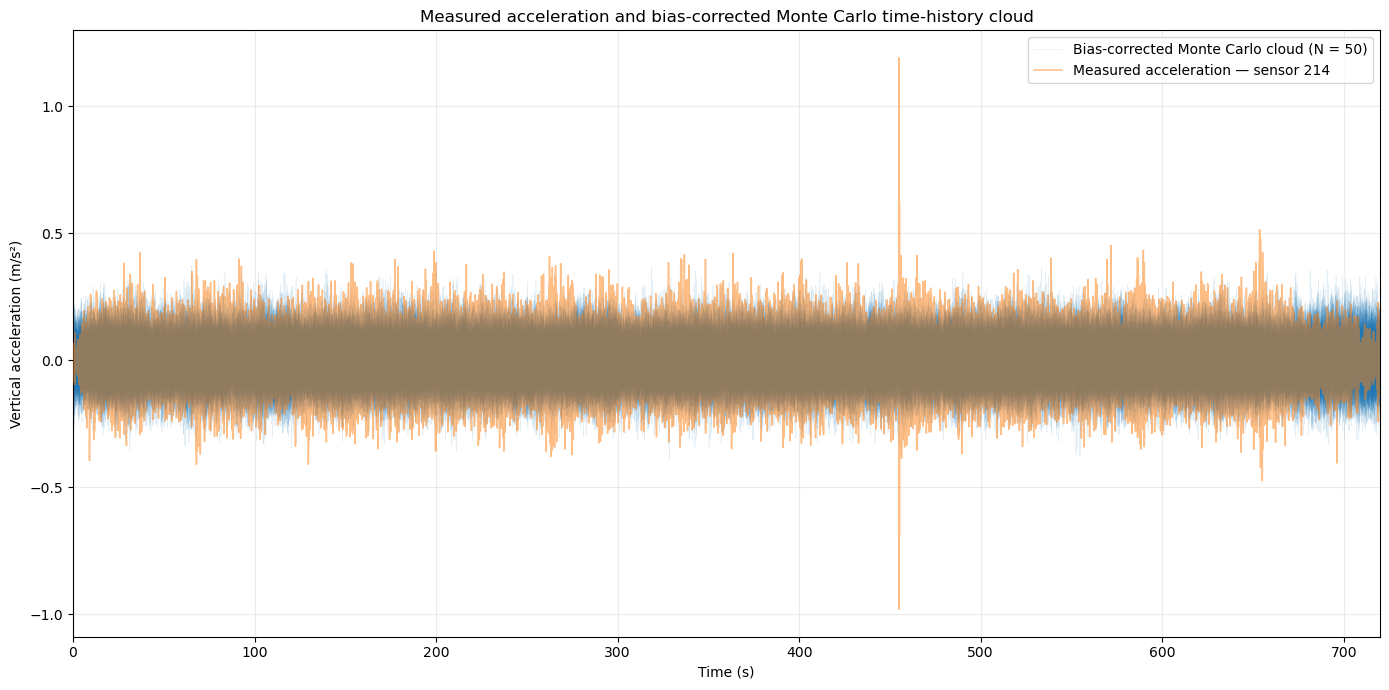

In [22]:
# ================================================================
# PLOT CORRECTED MONTE CARLO ACCELERATION CLOUD
# WITH MEASURED ACCELERATION ON TOP
# ================================================================

# Simulated time vector
time_simulated_for_bias = (
    np.arange(corrected_accelerations.shape[1])
    * hht
)

# Common plotting duration
common_end_time = min(
    time_measured_for_bias[-1],
    time_simulated_for_bias[-1]
)

plt.figure(figsize=(14, 7))


# ------------------------------------------------
# Plot all corrected Monte Carlo realizations
# ------------------------------------------------

for simulation_index in range(number_of_simulations):

    plt.plot(
        time_simulated_for_bias,
        corrected_accelerations[simulation_index],
        color="tab:blue",
        linewidth=0.45,
        alpha=0.12,
        rasterized=True,
        label=(
            f"Bias-corrected Monte Carlo cloud "
            f"(N = {number_of_simulations})"
            if simulation_index == 0
            else None
        )
    )


# ------------------------------------------------
# Plot measured history last, so it stays on top
# ------------------------------------------------

plt.plot(
    time_measured_for_bias,
    measured_acceleration_for_bias,
    color="tab:orange",
    linewidth=1.1,
    alpha=0.5,
    zorder=10,
    label="Measured acceleration — sensor 214"
)


plt.xlabel("Time (s)")
plt.ylabel("Vertical acceleration (m/s²)")

plt.title(
    "Measured acceleration and bias-corrected "
    "Monte Carlo time-history cloud"
)

plt.xlim(
    0.0,
    common_end_time
)

plt.grid(
    True,
    alpha=0.25
)

plt.legend()
plt.tight_layout()
plt.show()